# plot results of ensemble

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import fiona
import shapely.geometry
from pyproj import Geod
from ewatercycle.observation.grdc import get_grdc_data
from tqdm.notebook import tqdm


from src.paths import *
from src.forcing import generate_lumped_ERA5_forcing,load_lumped_forcing_data
from src.models import simulate_HBV,save_HBV_results
from src.utils import mmday_to_m3s
from src.constants import TYUMEN_ARYK_HBV_PARAMS_CMAES,PARAMETER_NAMES
import src.aral as aral

import glob

import glob
import os

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:

experiment_start_date = "1940-01-01T00:00:00Z"
experiment_end_date = "2020-12-31T00:00:00Z"

shapefile_kerki = "Kerki_GRDC"
shapefile_TA = "Tyumen_Aryk_GRDC"
shapefile_Aral = "AralSea"

Syr_kaza = aral.load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Amu_chatly = aral.load_grdc_monthly(2817100, name="Amu Darya Chatly")




In [3]:
# Tyumen Aryk / Syr Darya
output_dir_TA = OUTPUT_HBV / "Tyumen_Aryk_GRDC" / "ERA5"
pkl_files_TA = sorted(output_dir_TA.glob("Tyumen_Aryk_GRDC_ERA5_1940-2020_cmaes_*.pkl"))
rivers_TA = [aral.River.from_pickle(pkl, scaling=0.8) for pkl in pkl_files_TA]

# Kerki / Amu Darya
output_dir_Kerki = OUTPUT_HBV / "Kerki_GRDC" / "ERA5"  # <- fixed folder
pkl_files_Kerki = sorted(output_dir_Kerki.glob("Kerki_GRDC_ERA5_1940-2020_cmaes_*.pkl"))
rivers_Kerki = [aral.River.from_pickle(pkl, scaling=0.8) for pkl in pkl_files_Kerki]



In [4]:
aral_meteo = xr.open_dataset('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc')

# Initial settings
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

n_pairs = min(len(rivers_TA), len(rivers_Kerki))
ensemble_results = []

for i in tqdm(range(n_pairs), desc="Running paired Aral simulations"):
    ta_river = rivers_TA[i]
    kerki_river = rivers_Kerki[i]

    # Run the model
    df_aral = aral.run_connected_aral_model(
        aral_meteo,
        rivers=[kerki_river, ta_river],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2020-12-31",
        tqdm_position = 1,
    )

    # Optionally store metadata
    df_aral.attrs = {
        "pair_index": i,
        "Kerki_run": kerki_river.name,
        "Tyumen_Aryk_run": ta_river.name,
        "Kerki_parameters": getattr(kerki_river, "metadata", None),
        "Tyumen_Aryk_parameters": getattr(ta_river, "metadata", None),
    }

    ensemble_results.append(df_aral)

Running paired Aral simulations:   0%|          | 0/12 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

...

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25931 [00:00<?, ?it/s]

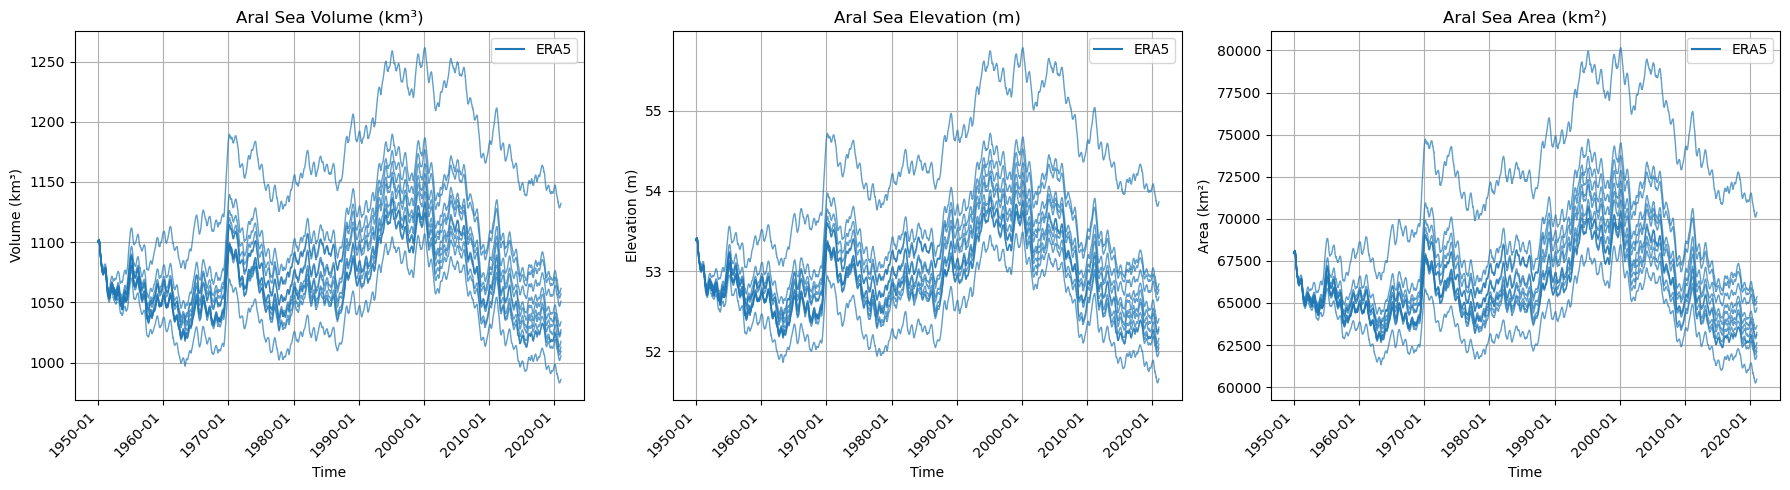

In [5]:
groups = ["ERA5"] * len(ensemble_results)

aral.plot_aral_ensemble_results(ensemble_results, groups=groups)

/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/src/aral.py:223: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.


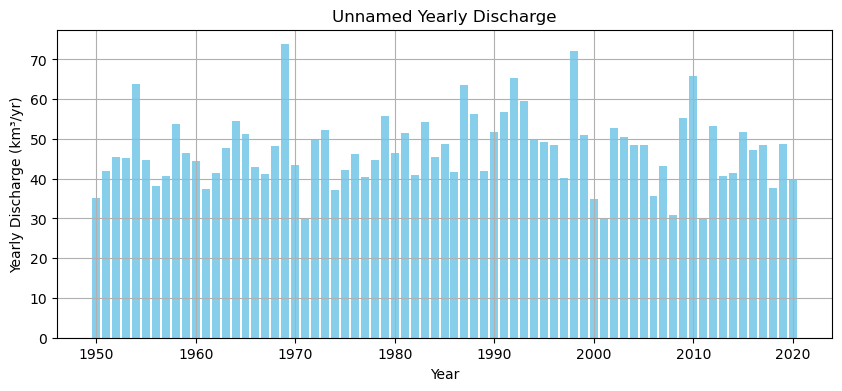

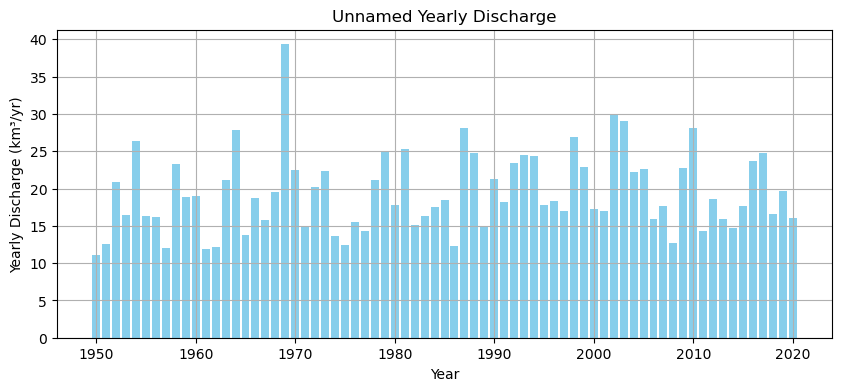

In [6]:
rivers_Kerki[0].plot_yearly()
rivers_TA[0].plot_yearly()

In [11]:
import pandas as pd
import xarray as xr
from pathlib import Path
import glob
import os

def make_obs(csv_file: Path, nc_folder: Path):
    """
    Load historical CSV and DAHITI NetCDF water level observations
    and return a list of tuples (DataFrame, label).

    Parameters
    ----------
    csv_file : Path
        Path to historical elevation CSV file
    nc_folder : Path
        Base folder where DAHITI NetCDF files are stored

    Returns
    -------
    obs_list : list of tuples
        Each tuple is (df, label), where df has columns ['time', 'elevation_m']
    """
    obs_list = []


    # ---------- CSV (historical table) ----------
    if csv_file.exists():
        df_csv = pd.read_csv(csv_file, sep=';', decimal=',')

        if not {'Year', 'elevation'}.issubset(df_csv.columns):
            raise ValueError(
                f"CSV must contain columns 'Year' and 'elevation'. Found: {df_csv.columns}"
            )

        df_csv = df_csv[['Year', 'elevation']].copy()
        df_csv['time'] = pd.to_datetime(df_csv['Year'], format='%Y')
        df_csv['elevation_m'] = df_csv['elevation'].astype(float)

        obs_list.append(
            (df_csv[['time', 'elevation_m']], 'Historical')
        )
    else:
        print(f"CSV file not found: {csv_file}")

    # --- Load all DAHITI NetCDF files ---
    nc_files = glob.glob(os.path.join(nc_folder, "**", "*.nc"), recursive=True)
    print(f"Found {len(nc_files)} NetCDF files in {nc_folder}")

    for nc_file in nc_files:
        ds = xr.open_dataset(nc_file)
        df_nc = pd.DataFrame({
            "time": pd.to_datetime(ds['datetime'].values),
            "elevation_m": ds['water_level'].values
        })
        obs_list.append((df_nc, 'Historical'))

    return obs_list


In [12]:
csv_file = BATHYMETRY / "Nachtnebel_table.csv"
nc_folder = DAHITI

observations = make_obs(csv_file, nc_folder)


Found 4 NetCDF files in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


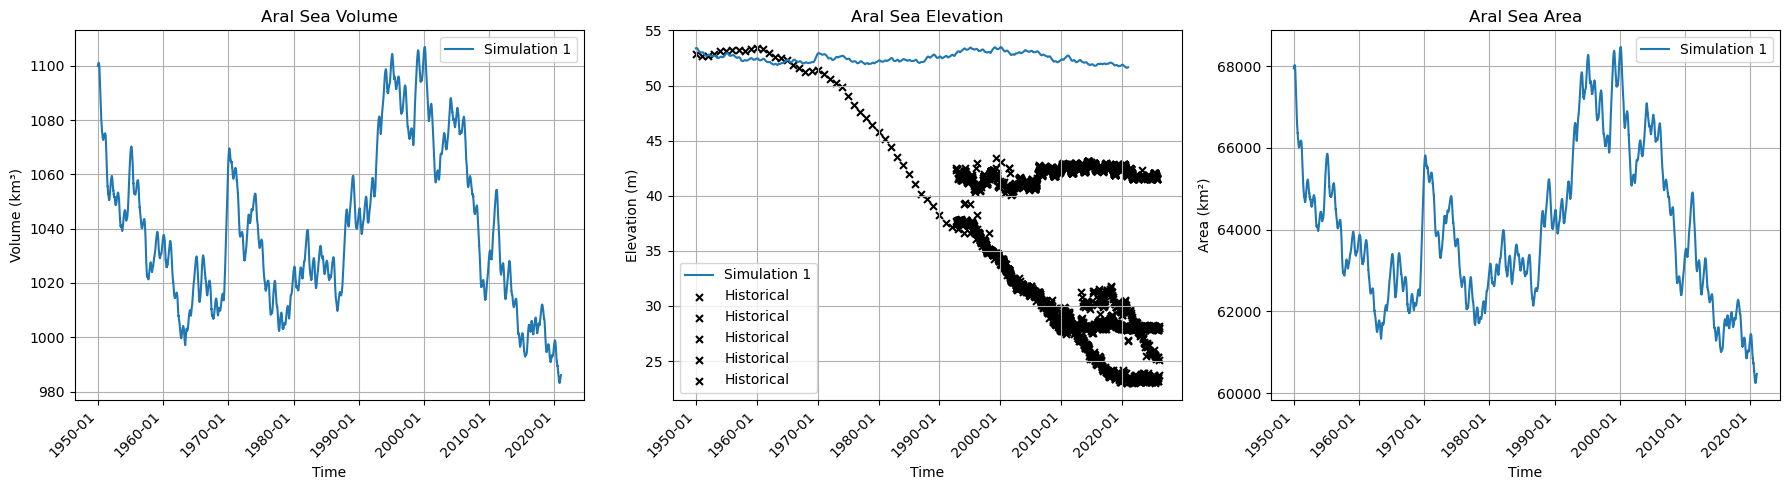

In [13]:
aral.plot_aral_results([ensemble_results[0]], observations=observations)

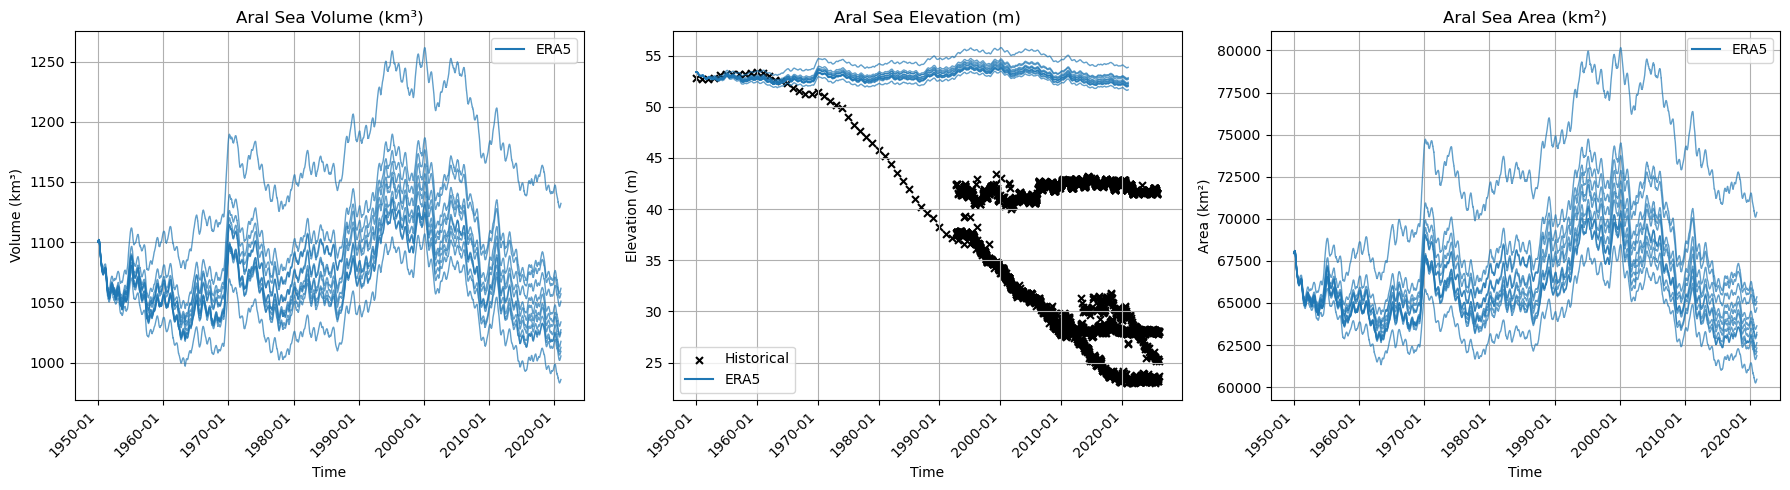

In [14]:
aral.plot_aral_ensemble_results(ensemble_results, groups=groups,observations=observations)